In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import os
from scipy.stats import gaussian_kde

In [7]:
# Parameters
n_population = 10000  # Full population size
n_sample = 2000  # Observed sample size
instrument_strength = 0.5  # Strength of the instrument's correlation with treatment uptake

def clinical_trial_model(p_treatment: float = 2., health_impact_treatment: float = None, health_impact_ability: float = None):
    # Generate true population data
    baseline_health = np.random.normal(0, 1, n_population)  # Unobserved baseline health factor
    if health_impact_treatment is None:
        health_impact_treatment = np.random.uniform(0.5, 5)  # 3
    if health_impact_ability is None:
        health_impact_ability = np.random.uniform(0.1, 1)  # 0.8
    
    # Instrument: distance to nearest treatment facility (affects treatment uptake but not health directly)
    distance_to_facility = np.clip(np.random.normal(10, 5, n_population), 1, 100)
    
    # Treatment uptake is influenced by baseline health and distance to the facility (the instrument)
    treatment_uptake = 1 + health_impact_ability * baseline_health - instrument_strength * distance_to_facility + np.random.normal(0, 1, n_population)
    treatment_uptake = (treatment_uptake > 0).astype(int)  # Binary treatment uptake (1 if treatment received, 0 otherwise)
    
    # Health outcome depends on treatment uptake and baseline health (baseline health is unobserved)
    true_health_outcomes = 50 + p_treatment * treatment_uptake + health_impact_treatment * baseline_health + np.random.normal(0, 2, n_population)
    true_health_outcomes[true_health_outcomes < 0] = 0  # Health outcomes cannot be negative
    
    # Create a participation probability based on baseline health
    participation_prob = np.clip(0.2 - 0.2 * baseline_health, 0, 1)
    participation = np.random.binomial(1, participation_prob, n_population)

    # Create observed sample (sample where individuals' health outcomes are observed)
    observed_indices = np.where(participation == 1)[0]
    _n_sample = min(n_sample, len(observed_indices))
    observed_sample_indices = np.random.choice(observed_indices, _n_sample, replace=False)
    
    # Create the observed sample data
    observed_data = pd.DataFrame({
        'treatment_uptake': treatment_uptake[observed_sample_indices],
        'distance_to_facility': distance_to_facility[observed_sample_indices],  # Instrument
        'true_health_outcomes': true_health_outcomes[observed_sample_indices],  # Actual health outcomes
    })
    
    # Full population data (for reference)
    population_data = pd.DataFrame({
        'treatment_uptake': treatment_uptake,
        'distance_to_facility': distance_to_facility,  # Instrument
        'true_health_outcomes': true_health_outcomes,  # Actual health outcomes for the full population
        'participation': participation  # Whether they are included in the observed sample
    })
    return observed_data, population_data


In [8]:
np.random.seed(42)
true_param = 2.0
obs, pop = clinical_trial_model(true_param, health_impact_treatment=0.8, health_impact_ability=3)

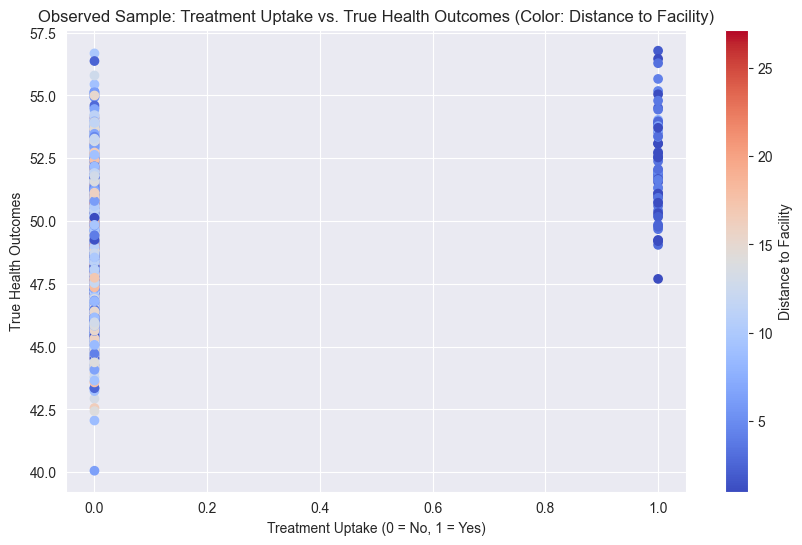

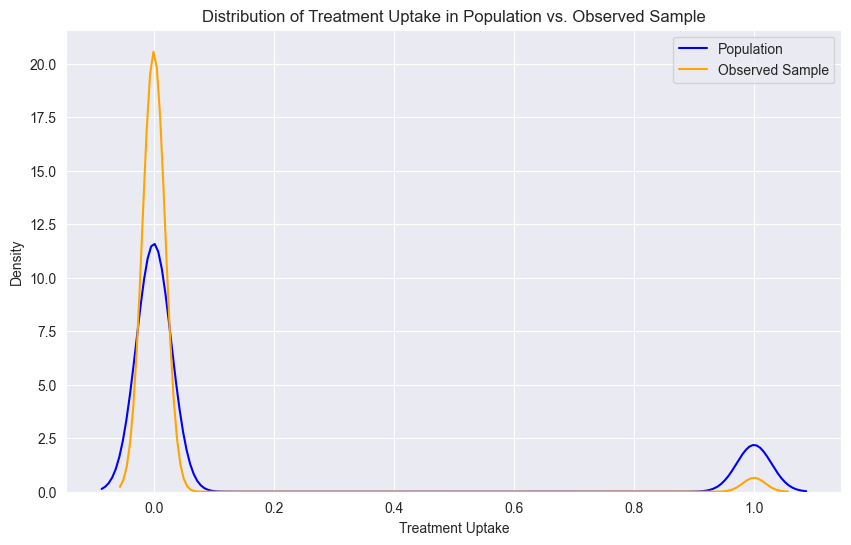

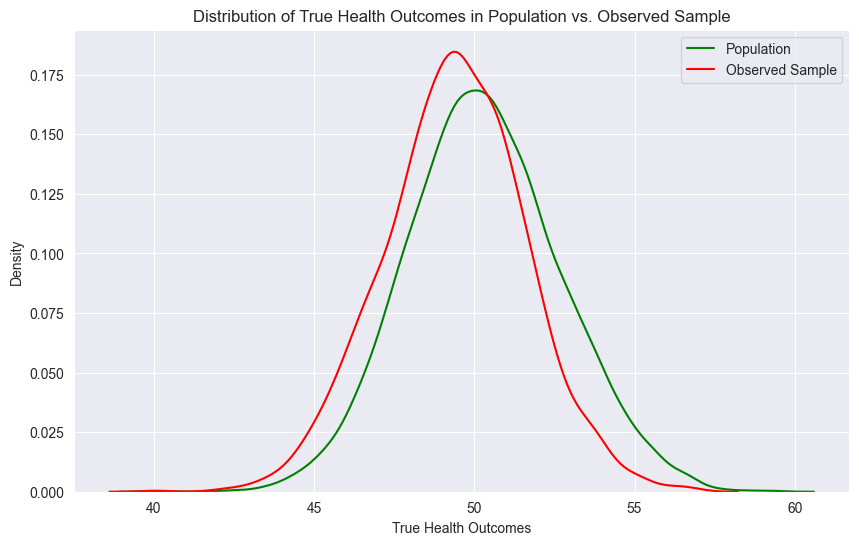

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizing the relationship between treatment uptake and true health outcomes in the observed sample
plt.figure(figsize=(10, 6))
scatter = plt.scatter(x=obs['treatment_uptake'], y=obs['true_health_outcomes'], c=obs['distance_to_facility'], cmap='coolwarm')
plt.title('Observed Sample: Treatment Uptake vs. True Health Outcomes (Color: Distance to Facility)')
plt.xlabel('Treatment Uptake (0 = No, 1 = Yes)')
plt.ylabel('True Health Outcomes')
plt.colorbar(scatter, label='Distance to Facility')
plt.show()

# Visualizing the distribution of treatment uptake in both the population and observed sample
plt.figure(figsize=(10, 6))
sns.kdeplot(pop['treatment_uptake'], label='Population', color='blue', bw_adjust=0.5)
sns.kdeplot(obs['treatment_uptake'], label='Observed Sample', color='orange', bw_adjust=0.5)
plt.title('Distribution of Treatment Uptake in Population vs. Observed Sample')
plt.xlabel('Treatment Uptake')
plt.ylabel('Density')
plt.legend()
plt.show()

# Visualizing the distribution of health outcomes in both the population and observed sample
plt.figure(figsize=(10, 6))
sns.kdeplot(pop['true_health_outcomes'], label='Population', color='green')
sns.kdeplot(obs['true_health_outcomes'], label='Observed Sample', color='red')
plt.title('Distribution of True Health Outcomes in Population vs. Observed Sample')
plt.xlabel('True Health Outcomes')
plt.ylabel('Density')
plt.legend()
plt.show()

In [10]:
# Prepare the data for OLS analysis
# Define dependent variable (outcome) and independent variable (treatment uptake)
Y = obs['true_health_outcomes']

# Use treatment uptake to estimate health outcomes
ols = sm.OLS(Y, sm.add_constant(obs['treatment_uptake'])).fit()
ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     true_health_outcomes   R-squared:                       0.052
Model:                              OLS   Adj. R-squared:                  0.052
Method:                   Least Squares   F-statistic:                     109.8
Date:                  Mon, 28 Oct 2024   Prob (F-statistic):           4.74e-25
Time:                          15:22:28   Log-Likelihood:                -4367.7
No. Observations:                  2000   AIC:                             8739.
Df Residuals:                      1998   BIC:                             8751.
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               49.2900      0.049   1009.587      0.000      49.194      49.386
treatment_uptake     2.9295      0.280     10.479      0.000       2.381       3.478
==============================================================================
Omnibus:                        6.078   Durbin-Watson:                   1.985
Prob(Omnibus):                  0.048   Jarque-Bera (JB):                6.086
Skew:                          -0.113   Prob(JB):                       0.0477
Kurtosis:                       3.149   Cond. No.                         5.82
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [11]:
# Prepare the data for IV analysis
# Define dependent variable (outcome) and independent variable (treatment uptake)

# Add a constant to the independent variable
X = sm.add_constant(obs['treatment_uptake'])

# Instrument: distance_to_facility (instrument for treatment uptake)
Z = sm.add_constant(obs['distance_to_facility'])  # Instrument for treatment uptake

# First stage: Predict treatment uptake using the instrument (distance to facility)
first_stage = sm.OLS(obs['treatment_uptake'], Z).fit()
obs['predicted_treatment_uptake'] = first_stage.predict(Z)

# Second stage: Use predicted treatment uptake to estimate health outcomes
second_stage = sm.OLS(Y, sm.add_constant(obs['predicted_treatment_uptake'])).fit()

# Display the results of the instrumental variable analysis
second_stage.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     true_health_outcomes   R-squared:                       0.003
Model:                              OLS   Adj. R-squared:                  0.003
Method:                   Least Squares   F-statistic:                     6.630
Date:                  Mon, 28 Oct 2024   Prob (F-statistic):             0.0101
Time:                          15:22:30   Log-Likelihood:                -4417.8
No. Observations:                  2000   AIC:                             8840.
Df Residuals:                      1998   BIC:                             8851.
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         49.2959      0.059    835.864      0.000      49.180      49.412
predicted_treatment_uptake     2.7334      1.062      2.575      0.010       0.652       4.815
==============================================================================
Omnibus:                        4.168   Durbin-Watson:                   2.001
Prob(Omnibus):                  0.124   Jarque-Bera (JB):                4.304
Skew:                          -0.069   Prob(JB):                        0.116
Kurtosis:                       3.181   Cond. No.                         21.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Use BayesFlow

In [12]:
import bayesflow as bf
from bayesflow.networks import InvertibleNetwork, DeepSet
from bayesflow.amortizers import AmortizedPosterior
from bayesflow.trainers import Trainer

/Users/jonas.arruda/miniconda/envs/SamplingBias/lib/python3.10/site-packages/bayesflow/trainers.py:27: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [13]:
posterior_samples_dict = {
    'instrument_observed': None,
    'no_instrument_observed': None,
}

In [39]:
instrument_observed = True

In [40]:
def generative_model(n_samples: int = None, param_batch: np.ndarray = None):
    if param_batch is None:
        if n_samples is None:
            raise ValueError("Either n_samples or param_batch must be provided.")
        param_batch = np.random.uniform(0, 5, size=(n_samples, 1))
    
    # Initialize data array
    data = np.zeros((len(param_batch), n_sample, 3 if instrument_observed else 2))
    for i, param in enumerate(param_batch):
        # Generate data for the clinical model with the given parameter
        data_i, _ = clinical_trial_model(param[0])  # Only one parameter in the batch
        
        # Include instrument in data if observed, otherwise exclude it
        if instrument_observed:
            data_i = data_i[['true_health_outcomes', 'treatment_uptake', 'distance_to_facility']].values
        else:
            data_i = data_i[['true_health_outcomes', 'treatment_uptake']].values
            
        # Ensure data has the correct sample size, pad if necessary
        if data_i.shape[0] < n_sample:
            data_i = np.pad(data_i, ((0, n_sample - data_i.shape[0]), (0, 0)), mode='constant', constant_values=-0.1)
        
        data[i] = data_i  # Assign to batch data
    
    return {'sim_data': data, 'prior_draws': param_batch}


In [41]:
param_names = ['treatment_uptake']
param_names

['treatment_uptake']

In [42]:
summary_net = DeepSet(summary_dim=2)

inference_net = InvertibleNetwork(
    num_params=len(param_names),
    num_coupling_layers=3,
    permutation="learnable"
)
amortizer = AmortizedPosterior(
    inference_net=inference_net,
    summary_net=summary_net,
)

In [43]:
np.random.seed(42)
_sim_data = generative_model(1000)
prior_mean = _sim_data['prior_draws'].mean(axis=0)
prior_std = _sim_data['prior_draws'].std(axis=0)
x_mean = np.log1p(_sim_data['sim_data']).mean(axis=0)
x_std = np.log1p(_sim_data['sim_data']).std(axis=0)

In [44]:
def configurator(forward_dict: dict) -> dict:
    # Extract data
    x = forward_dict["sim_data"]
    x = np.log1p(x)
    x = (x - x_mean) / x_std
    out_dict = {
        'summary_conditions': x.astype(np.float32)
    }

    # Extract params
    if 'parameters' in forward_dict.keys():
        forward_dict["prior_draws"] = forward_dict["parameters"]
    if 'prior_draws' in forward_dict.keys():
        params = forward_dict["prior_draws"]
        # normalize
        params = (params - prior_mean) / prior_std
        out_dict['parameters'] = params.astype(np.float32)
    return out_dict

In [45]:
trainer = Trainer(
    amortizer=amortizer,
    configurator=configurator,
    generative_model=generative_model,
    #checkpoint_path='amortizer_education_IV' if instrument_observed else 'amortizer_education',
)

INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


In [46]:
%%time
np.random.seed(42)
offline_data = generative_model(10000)
valid_data = generative_model(256)
prior_draws = valid_data['prior_draws']

CPU times: user 14.3 s, sys: 419 ms, total: 14.7 s
Wall time: 14.8 s


In [47]:
if True: #not os.path.exists(trainer.checkpoint_path):
    history = trainer.train_offline(
        simulations_dict=offline_data,
        epochs=30,
        batch_size=128,
        early_stopping=True,
        validation_sims=valid_data
    )
else:
    trainer.load_pretrained_network()
    history = trainer.loss_history.get_plottable()

Training epoch 1:   0%|          | 0/79 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 1, Loss: 1.364


Training epoch 2:   0%|          | 0/79 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 2, Loss: 0.484


Training epoch 3:   0%|          | 0/79 [00:00<?, ?it/s]

...

INFO:root:Validation, Epoch: 28, Loss: -0.066


Training epoch 29:   0%|          | 0/79 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 29, Loss: -0.062


Training epoch 30:   0%|          | 0/79 [00:00<?, ?it/s]

INFO:root:Validation, Epoch: 30, Loss: -0.060
INFO:root:Early stopping triggered.


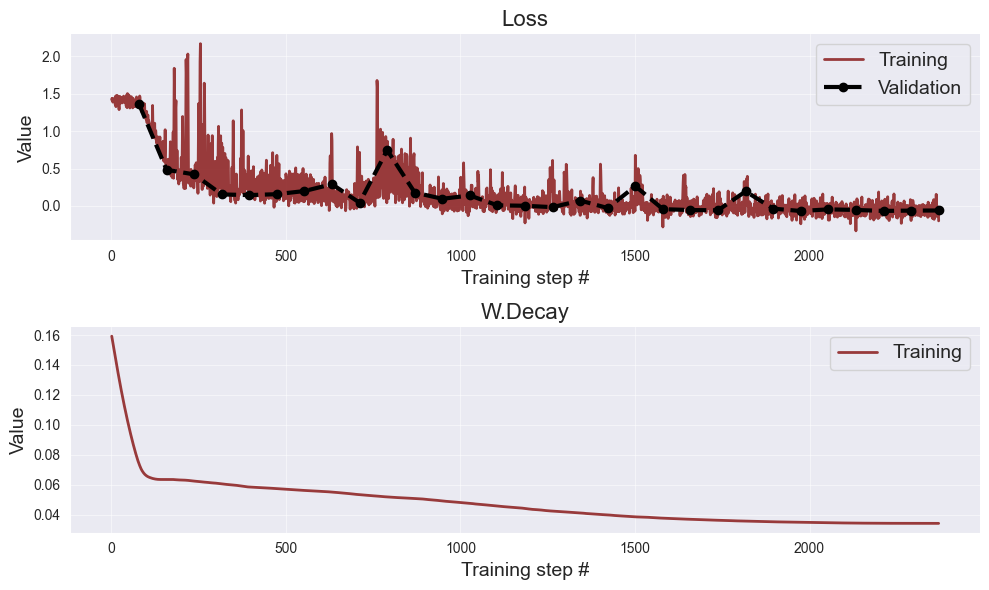

In [48]:
bf.diagnostics.plot_losses(history['train_losses'], history['val_losses'], fig_size=(10, 6));

In [49]:
posterior_samples = trainer.amortizer.sample(trainer.configurator(valid_data), n_samples=100)
posterior_samples = posterior_samples * prior_std + prior_mean

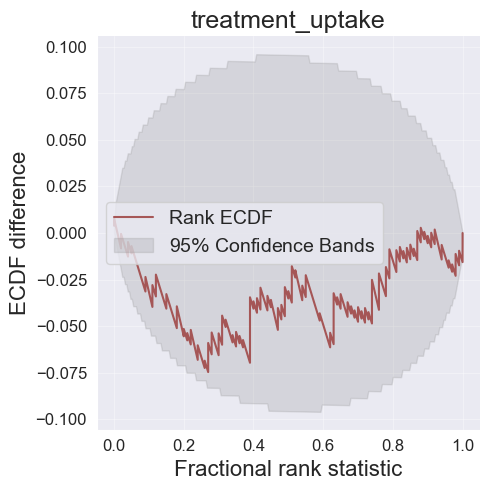

In [50]:
bf.diagnostics.plot_sbc_ecdf(posterior_samples, prior_draws, difference=True, param_names=param_names);

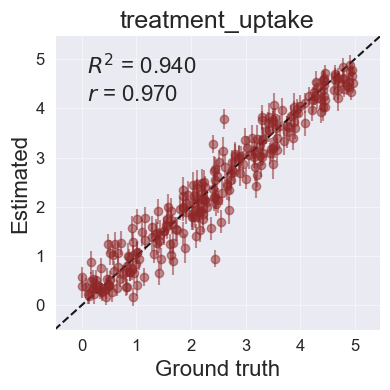

In [51]:
bf.diagnostics.plot_recovery(posterior_samples, prior_draws, param_names=param_names);

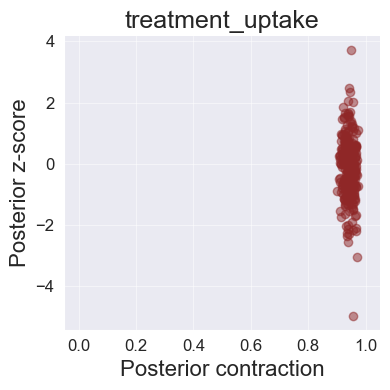

In [52]:
bf.diagnostics.plot_z_score_contraction(posterior_samples, prior_draws, param_names=param_names);

## Test Data

In [53]:
if instrument_observed:
    test_data = {'sim_data': obs[['true_health_outcomes', 'treatment_uptake', 'distance_to_facility']].values[np.newaxis]}
else:
    test_data = {'sim_data': obs[['true_health_outcomes', 'treatment_uptake']].values[np.newaxis]}
    
# Generate posterior samples using the trainer's amortizer and configurator for the test data
posterior_samples = trainer.amortizer.sample(trainer.configurator(test_data), n_samples=1000)

# Adjust posterior samples by scaling with prior standard deviation and mean
posterior_samples = posterior_samples * prior_std + prior_mean

# Store posterior samples based on whether the instrument is observed
if instrument_observed:
    posterior_samples_dict['instrument_observed'] = posterior_samples.copy()
else:
    posterior_samples_dict['no_instrument_observed'] = posterior_samples.copy()

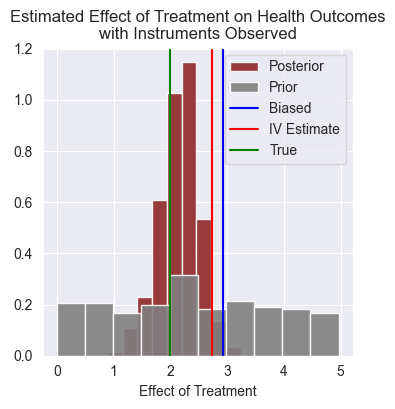

In [54]:
fig = plt.figure(figsize=(4, 4))
plt.hist(posterior_samples, density=True, alpha=0.9, color="#8f2727", label='Posterior')
plt.hist(prior_draws, density=True, alpha=0.9, color="gray", label='Prior')

# Add reference lines for different estimates
plt.axvline(ols.params['treatment_uptake'], color='b', label='Biased')
plt.axvline(second_stage.params['predicted_treatment_uptake'], color='r', label='IV Estimate')
plt.axvline(true_param, color='g', label='True')
plt.legend()
plt.xlabel('Effect of Treatment')
plt.title(f'Estimated Effect of Treatment on Health Outcomes\n{"with Instruments Observed" if instrument_observed else ""}')
plt.show()

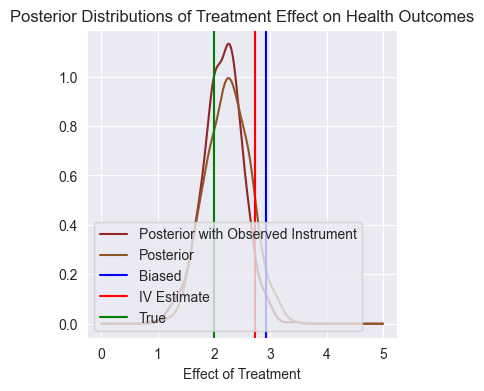

In [55]:
if posterior_samples_dict['instrument_observed'] is not None and posterior_samples_dict['no_instrument_observed'] is not None:
    fig = plt.figure(figsize=(4, 4))
    x = np.linspace(0, 5, 1000)
    
    # KDE plot for posterior samples with observed instrument
    kde = gaussian_kde(posterior_samples_dict['instrument_observed'].flatten())
    plt.plot(x, kde(x), color='#8f2727', label='Posterior with Observed Instrument')
    
    # KDE plot for posterior samples without observed instrument
    kde_no = gaussian_kde(posterior_samples_dict['no_instrument_observed'].flatten())
    plt.plot(x, kde_no(x), color='#8f5727', label='Posterior')
    
    # Add reference lines for different estimates
    plt.axvline(ols.params['treatment_uptake'], color='b', label='Biased')
    plt.axvline(second_stage.params['predicted_treatment_uptake'], color='r', label='IV Estimate')
    plt.axvline(true_param, color='g', label='True')
    
    plt.legend(loc='lower left')
    plt.xlabel('Effect of Treatment')
    plt.title('Posterior Distributions of Treatment Effect on Health Outcomes')
    plt.show()